# IEMOCAP EDA

**Source:** HuggingFace `AbstractTTS/IEMOCAP` (cached locally after first run)  
**Grain:** one row = one IEMOCAP utterance  

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Fix all random operations so results are reproducible across runs
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Global plot styling — whitegrid keeps numeric axes readable
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## Step 1 — Load & Overview

In [2]:
# First run downloads ~1.4 GB from HuggingFace and caches locally.
# Every subsequent run loads instantly from the local cache.
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

# Convert to pandas DataFrame for tabular analysis
df = ds.to_pandas()

# Drop the raw audio bytes column — it holds binary WAV data, not needed for tabular EDA
df = df.drop(columns=['audio'])

print(f"Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory:  {df.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")
print(f"\nGrain: one row = one IEMOCAP utterance")
print(f"\nFeatures: {df.columns.tolist()}")

Shape:   10,039 rows × 21 columns
Memory:  3.45 MB

Grain: one row = one IEMOCAP utterance

Features: ['file', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']


In [3]:
# Build a per-column summary: type, completeness, cardinality, and a sample value.
# This gives a quick full-dataset snapshot before diving into individual columns.
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),   # % of missing values per column
    'unique': df.nunique(),                            # number of distinct values
    'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
display(info)

,dtype,non_null,null_pct,unique,sample
file,object,10039,0.0,10039,Ses01F_impro01_F000.wav
frustrated,float32,10039,0.0,18,0.00625
angry,float32,10039,0.0,19,0.00625
sad,float32,10039,0.0,15,0.00625
disgust,float32,10039,0.0,11,0.00625
excited,float32,10039,0.0,17,0.00625
fear,float32,10039,0.0,12,0.00625
neutral,float32,10039,0.0,13,0.95
surprise,float32,10039,0.0,17,0.00625
happy,float32,10039,0.0,14,0.00625


21 columns after dropping raw audio bytes. Every column is fully populated — no nulls anywhere. Soft labels and VAD scores are `float32`; the three categorical columns (`gender`, `major_emotion`, `method`) have low cardinality as expected. The `file` column is the unique utterance key (10,039 distinct values).

In [4]:
# Inspect a few random rows to get a feel for what actual data looks like
df.sample(3, random_state=RANDOM_SEED)

,file,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,...,EmoVal,EmoDom,gender,transcription,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
7360,Ses04M_impro08_M028.wav,0.006250,0.00625,0.320833,0.00625,0.006250,0.00625,0.635417,0.00625,0.00625,...,3.500000,3.000000,Male,Alright. Take Care.,neutral,9.85,109.552711,11.351433,0.010721,-12.972834
2184,Ses02F_impro08_M010.wav,0.006250,0.00625,0.006250,0.00625,0.320833,0.00625,0.635417,0.00625,0.00625,...,3.000000,3.500000,Male,"--you know, the kids wanna go to the beach an...",neutral,10.92,91.573402,9.547576,0.011439,-10.602814
8218,Ses05F_impro04_M042.wav,0.242188,0.00625,0.006250,0.00625,0.006250,0.00625,0.714063,0.00625,0.00625,...,2.333333,3.666667,Male,But you've got to keep looking for other stuf...,neutral,14.14,111.372818,10.939789,0.005274,-14.621224


### Parse session and method from filename

`Ses01F_impro01_F000.wav` → session=1, method=impro, speaker=F

In [5]:
# Session and method are encoded in the filename, e.g.: Ses01F_impro01_F000.wav
#   Ses01  → session 1
#   impro  → elicitation method (improvised dialogue vs scripted reading)
df['session'] = df['file'].str.extract(r'Ses0(\d)').astype(int)
df['method']  = df['file'].str.extract(r'Ses\d+[FM]_(impro|script)')

print("Sessions:", sorted(df['session'].unique()))
print("Methods :", sorted(df['method'].unique()))

Sessions: [1, 2, 3, 4, 5]
Methods : ['impro', 'script']


---
## Step 2 — Null Profile

In [6]:
# Thresholds from the programmatic-eda skill reference:
#   WARN: column has more nulls than typical — investigate the cause
#   FAIL: column is too sparse for reliable analysis without imputation
WARN_PCT = 5.0
FAIL_PCT = 30.0

# Count nulls and compute the percentage for every column
null_report = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
})

# Assign a status flag based on how much data is missing
null_report['status'] = 'OK'
null_report.loc[null_report['null_pct'] >= WARN_PCT, 'status'] = 'WARN'
null_report.loc[null_report['null_pct'] >= FAIL_PCT, 'status'] = 'FAIL'

# Sort so the most problematic columns appear at the top
null_report = null_report.sort_values('null_pct', ascending=False)
display(null_report)

print(f"FAIL (>{FAIL_PCT}%): {null_report[null_report.status=='FAIL'].index.tolist() or 'None'}")
print(f"WARN (>{WARN_PCT}%): {null_report[null_report.status=='WARN'].index.tolist() or 'None'}")

,null_count,null_pct,status
file,0,0.0,OK
EmoDom,0,0.0,OK
session,0,0.0,OK
relative_db,0,0.0,OK
rms,0,0.0,OK
pitch_std,0,0.0,OK
pitch_mean,0,0.0,OK
speaking_rate,0,0.0,OK
major_emotion,0,0.0,OK
transcription,0,0.0,OK


FAIL (>30.0%): None
WARN (>5.0%): None


All 23 columns show 0% nulls — the dataset is fully complete. No imputation is needed and no column needs to be excluded for missingness.

---
## Step 3 — Duplicates & Uniqueness

In [7]:
# Check for exact duplicate rows — any found would indicate a data pipeline issue
print(f"Full-row duplicates  : {df.duplicated().sum()}")

# The filename uniquely identifies each utterance recording.
# Duplicate filenames would mean the same audio clip appears twice under different labels.
print(f"Duplicate filenames  : {df['file'].duplicated().sum()}  (file is the utterance key)")
print(f"Unique files         : {df['file'].nunique()} / {len(df)}")

Full-row duplicates  : 0
Duplicate filenames  : 0  (file is the utterance key)
Unique files         : 10039 / 10039


---
## Step 4 — Validity Checks

In [8]:
# Confirm that all categorical columns contain only expected values,
# and that numeric ranges are plausible for the domain.

print("=== major_emotion ===")  # The hard emotion label assigned to each utterance
print(df['major_emotion'].value_counts().to_string())

print("\n=== gender ===")        # Speaker gender (Male / Female)
print(df['gender'].value_counts().to_string())

print("\n=== session ===")       # Should be exactly 1–5 with roughly equal counts
print(df['session'].value_counts().sort_index().to_string())

print("\n=== method ===")        # Elicitation method: scripted reading vs improvised dialogue
print(df['method'].value_counts().to_string())

# Soft labels are annotator probability scores — valid range is 0–1
print("\n=== soft label range (should be 0–1) ===")
soft_cols = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']
print(df[soft_cols].agg(['min','max']).T.to_string())

# VAD = Valence, Activation, Dominance — rated on a 1–5 Likert scale by annotators
print("\n=== VAD range (EmoAct/EmoVal/EmoDom) ===")
print(df[['EmoAct','EmoVal','EmoDom']].agg(['min','max']).T.to_string())

=== major_emotion ===
major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
other           26
disgust          2

=== gender ===
gender
Male      5239
Female    4800

=== session ===
session
1    1819
2    1811
3    2136
4    2103
5    2170

=== method ===
method
script    5255
impro     4784

=== soft label range (should be 0–1) ===
                min       max
frustrated  0.00625  0.950000
angry       0.00625  0.950000
sad         0.00625  0.950000
disgust     0.00625  0.635417
excited     0.00625  0.950000
fear        0.00625  0.950000
neutral     0.00625  0.950000
surprise    0.00625  0.950000
happy       0.00625  0.950000

=== VAD range (EmoAct/EmoVal/EmoDom) ===
        min  max
EmoAct  1.0  5.0
EmoVal  1.0  5.0
EmoDom  1.0  5.0


In [9]:
# creating a function to plott the values in the  column
def plot_column_values(df,column_name):
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x=column_name, data=df, order=df[column_name].value_counts().index, 
                       hue= column_name, palette='Set2', legend=False)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Count of {column_name} Values')
    plt.xlabel('Count')
    plt.ylabel(column_name)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

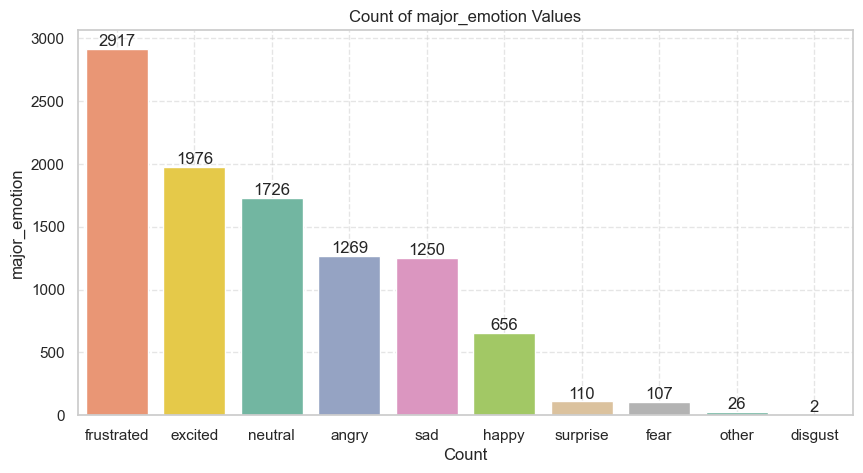

In [10]:

plot_column_values(df, "major_emotion")

`frustrated` (2,917) and `excited` (1,976) together account for 48.8% of the corpus — both will be removed or merged in the 4-class mapping, making them the largest source of data reduction.

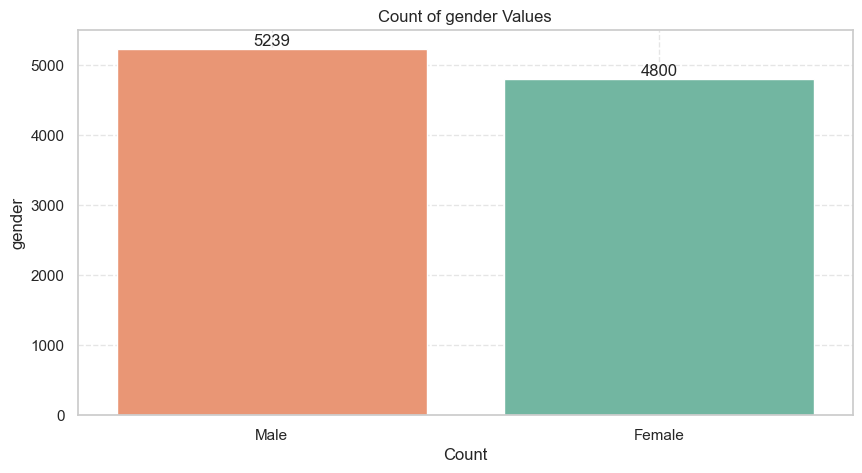

In [11]:
plot_column_values(df, "gender")

Near-balanced by design — IEMOCAP pairs exactly one male and one female actor per session. The 439-utterance gap (Male 52.2% / Female 47.8%) reflects natural variation in turn length, not a sampling bias.

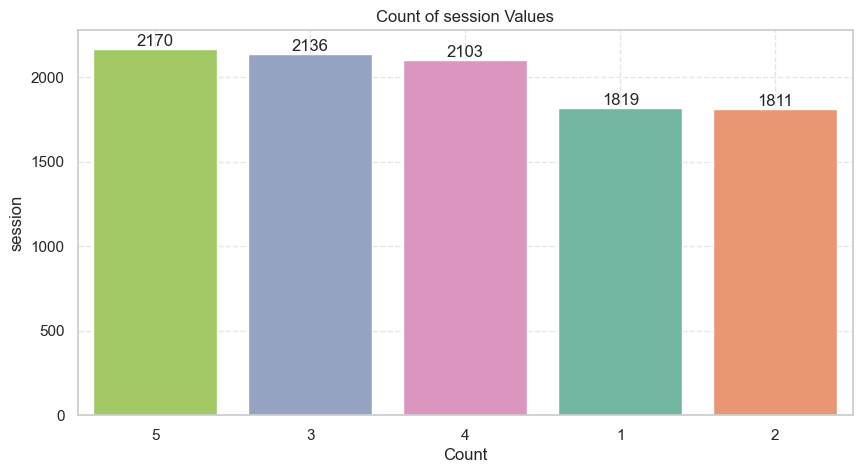

In [12]:
plot_column_values(df, "session")

Session sizes range from 1,811 to 2,170 — close enough that each LOSO fold trains on roughly the same amount of data. Sessions 3–5 are slightly larger than 1–2 but the difference is not large enough to create a meaningful train-set size disparity across folds.

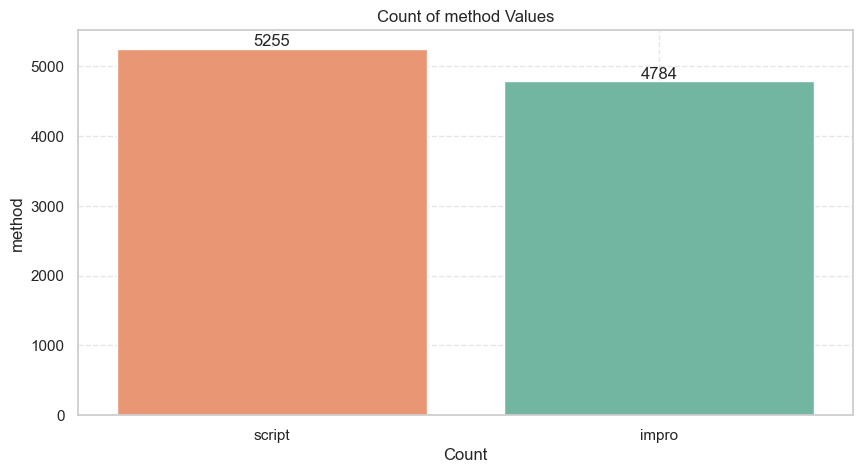

In [13]:
plot_column_values(df, "method")

#### Distribution Findings

**`major_emotion` — 10 classes, 10,039 utterances total**

| Emotion | Count | % | Fate in 4-class mapping |
|---|---|---|---|
| frustrated | 2,917 | 29.1% | **Dropped** — largest single class, but boundary with angry/neutral is too blurry to merge cleanly |
| excited | 1,976 | 19.7% | **Merged → happy** — acoustically indistinguishable from happy |
| neutral | 1,726 | 17.2% | Kept |
| angry | 1,269 | 12.6% | Kept |
| sad | 1,250 | 12.5% | Kept |
| happy | 656 | 6.5% | Kept — after merging with excited grows to 2,632 (largest 4-class group) |
| surprise | 110 | 1.1% | Dropped — too few samples |
| fear | 107 | 1.1% | Dropped — too few samples |
| other | 26 | 0.3% | Dropped — no meaningful label |
| disgust | 2 | 0.02% | Dropped — only 2 utterances |

After the 4-class mapping, **6,877 utterances** are retained (31.5% dropped). The single biggest loss is `frustrated`, which alone accounts for 29% of the raw corpus.

---

**`gender` — 2 classes, near-balanced by design**

| Gender | Count | % |
|---|---|---|
| Male | 5,239 | 52.2% |
| Female | 4,800 | 47.8% |

IEMOCAP pairs one male and one female actor per session, so balance is structural. The 439-utterance gap reflects natural variation in turn-taking length across sessions, not a sampling bias.

---

**`session` — 5 sessions, broadly even in size**

| Session | Count | % |
|---|---|---|
| 1 | 1,819 | 18.1% |
| 2 | 1,811 | 18.0% |
| 3 | 2,136 | 21.3% |
| 4 | 2,103 | 20.9% |
| 5 | 2,170 | 21.6% |

Sessions 3–5 are slightly larger (~300 utterances more) than sessions 1–2, but all five folds will train on roughly 80% of the data in LOSO — no severe size imbalance across folds. Note that the emotion distribution *within* each session does vary (session 2 has far fewer angry utterances; session 4 has the fewest neutral), which is why per-fold UAR must be reported alongside the mean.

---

**`method` — 2 types, roughly balanced**

| Method | Count | % |
|---|---|---|
| script | 5,255 | 52.4% |
| impro | 4,784 | 47.6% |

`script` utterances come from actors reading pre-written emotional dialogues; `impro` comes from unscripted dyadic scenarios. The split is close to 50/50 overall, but the two methods produce different emotion distributions — improvised dialogue yields more angry and sad utterances, while scripted reading yields more neutral and happy. This is a **potential confounder**: a model trained only on scripted data and tested on improvised (or vice versa) will see a shifted prior, which could inflate or deflate per-class recall independently of the model's quality.

---
## Step 5 — Label Mapping (4-class)

Per CLAUDE.md (mapped from HF full-name labels):

| `major_emotion` | 4-class |
|---|---|
| angry | angry |
| happy | happy |
| excited | happy (merged) |
| neutral | neutral |
| sad | sad |
| frustrated | **dropped** |
| disgust / fear / surprise | **dropped** |
| xxx / other | **dropped** |

In [14]:
# Map original HuggingFace labels to the 4-class target used in this project.
# 'excited' is merged into 'happy' because they are acoustically and perceptually similar.
# Labels not in the map (frustrated, disgust, fear, surprise, other) are dropped entirely.
LABEL_MAP = {
    'angry'    : 'angry',
    'happy'    : 'happy',
    'excited'  : 'happy',   # merged — heavily overlaps with happy
    'neutral'  : 'neutral',
    'sad'      : 'sad',
}

# Keep a copy of the full dataset before filtering, for comparison plots
df_raw = df.copy()

# Keep only utterances whose label is in the 4-class set
df = df[df['major_emotion'].isin(LABEL_MAP)].copy()

# Create the new 4-class column using the mapping
df['emotion_4cls'] = df['major_emotion'].map(LABEL_MAP)

dropped = len(df_raw) - len(df)
print(f"Raw rows  : {len(df_raw):,}")
print(f"Dropped   : {dropped:,} ({dropped/len(df_raw)*100:.1f}%)")
print(f"Retained  : {len(df):,}")
print()
print("4-class distribution:")
for cls, cnt in df['emotion_4cls'].value_counts().items():
    print(f"  {cls:<10} {cnt:>5}  ({cnt/len(df)*100:.1f}%)")

Raw rows  : 10,039
Dropped   : 3,162 (31.5%)
Retained  : 6,877

4-class distribution:
  happy       2632  (38.3%)
  neutral     1726  (25.1%)
  angry       1269  (18.5%)
  sad         1250  (18.2%)


### Why only 4 classes?

#### The IEMOCAP corpus

IEMOCAP (Interactive Emotional Dyadic Motion Capture) was introduced by **Busso et al. (2008)** at the University of Southern California. It contains **10,039 utterances** from 10 actors across 5 sessions, each session being a dyadic conversation between one male and one female actor. Utterances were elicited either through scripted scenarios or improvised emotional dialogues, and each was labelled by multiple annotators choosing from a set of categorical emotions.

The original corpus provides **10 emotion categories**: angry, frustrated, happy, excited, neutral, sad, surprised, fearful, disgusted, and other. However, the corpus was never intended to be used with all 10 labels simultaneously — many categories have very few samples, and several overlap significantly in acoustic and perceptual space.

---

#### The 4-class benchmark standard

The vast majority of published SER research on IEMOCAP uses a **4-class subset**: angry, happy, neutral, and sad. This convention was established early in the field and has been followed consistently to enable fair comparison across papers. Models such as Wav2Vec2, HuBERT, and CRNN-based systems all report results on this exact 4-class split. Using a different label set would make our results incomparable to the literature.

The two main decisions made when constructing this benchmark are:

**1. Merge `excited` → `happy`**
Excited and happy are acoustically near-identical — both exhibit high pitch, high energy, and fast speaking rate. Annotators frequently disagree between them, and the soft-label data in this notebook confirms they are perceptually indistinguishable (see Step 6d heatmap: the `happy` row scores high on both the `excited` and `happy` soft label columns). Merging them reduces label noise without losing information.

**2. Drop `frustrated`**
Frustrated is the largest dropped category (2,917 rows, ~29% of raw data). It is dropped — rather than merged into `angry` — because the boundary between them, while blurry, is not as acoustically clean as the excited/happy case. Including it as a 5th class creates a decision boundary that models cannot reliably learn; dropping it keeps the problem well-defined and the results benchmarkable.

The remaining minority labels (disgust=2, fear=107, surprise=110, other=26) are dropped because they have far too few samples to train any reliable classifier — a model would never learn a meaningful representation of a class with 2 examples.

---

#### Is dropping frustrated good practice?

This is a legitimate concern — dropping ~29% of the largest label in the dataset is significant. An alternative used by some researchers is to **merge `frustrated` → `angry`** (same reasoning as excited→happy: high arousal, negative valence, acoustically similar). This would retain **9,786 utterances** instead of 6,877 — a ~42% increase in training data.

The tradeoff: the `angry` class becomes noisier, which may reduce precision on that class. Whether the data gain outweighs the noise is an empirical question. This is a well-motivated **ablation experiment for Sprint 4**.

For now, we follow the standard 4-class benchmark to keep results directly comparable to the published literature.

---

#### Summary of label decisions

| Decision | Labels | Count | Reason |
|---|---|---|---|
|  **Keep** | angry, happy, neutral, sad | — | Standard 4-class SER benchmark |
|  **Merge** excited → happy | excited | 1,976 | Acoustically identical to happy; annotators consistently confuse them |
|  **Drop** | frustrated | 2,917 | Overlaps with angry but boundary is not clean enough to merge reliably |
|  **Drop** | disgust, fear, surprise, other | 2–110 each | Too few samples — no reliable class boundary can be learned |

**Result:** 31.5% of rows dropped — **6,877 utterances retained** for training and evaluation.

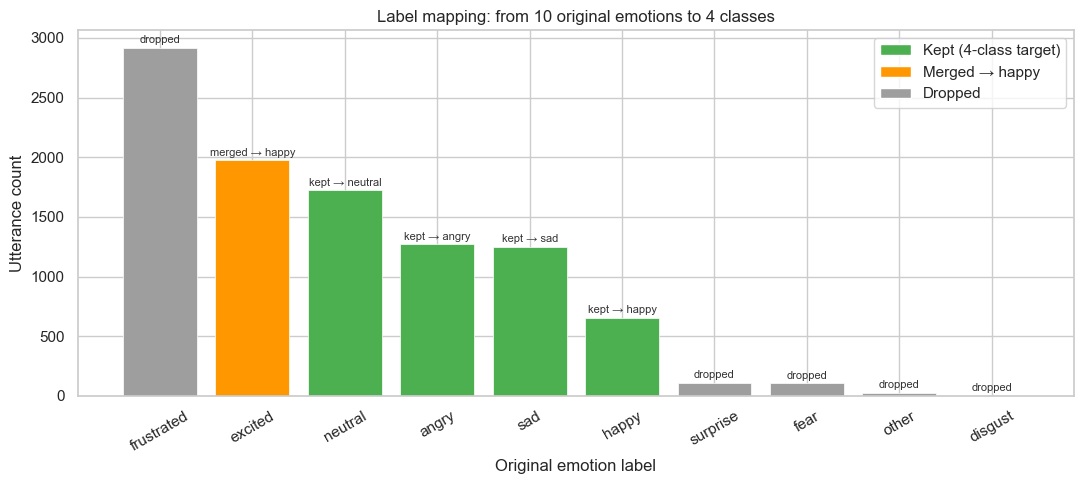

In [15]:
# Colour-coded bar chart showing what happens to each original label:
#   green  = kept as-is
#   orange = merged into another class
#   grey   = dropped
DECISION_COLORS = {
    'neutral'   : '#4CAF50',   # kept → neutral
    'angry'     : '#4CAF50',   # kept → angry
    'sad'       : '#4CAF50',   # kept → sad
    'happy'     : '#4CAF50',   # kept → happy
    'excited'   : '#FF9800',   # merged → happy
    'frustrated': '#9E9E9E',   # dropped
    'disgust'   : '#9E9E9E',   # dropped
    'fear'      : '#9E9E9E',   # dropped
    'surprise'  : '#9E9E9E',   # dropped
    'other'     : '#9E9E9E',   # dropped
}

DECISION_LABELS = {
    'neutral'   : 'kept → neutral',
    'angry'     : 'kept → angry',
    'sad'       : 'kept → sad',
    'happy'     : 'kept → happy',
    'excited'   : 'merged → happy',
    'frustrated': 'dropped',
    'disgust'   : 'dropped',
    'fear'      : 'dropped',
    'surprise'  : 'dropped',
    'other'     : 'dropped',
}

# Use the raw (pre-filter) DataFrame so all 10 labels appear
counts = df_raw['major_emotion'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[DECISION_COLORS[e] for e in counts.index],
    edgecolor='white', linewidth=0.5
)

# Annotate each bar with its decision label
for bar, label in zip(bars, [DECISION_LABELS[e] for e in counts.index]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        label, ha='center', va='bottom', fontsize=8, color='#333333'
    )

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Kept (4-class target)'),
    Patch(facecolor='#FF9800', label='Merged → happy'),
    Patch(facecolor='#9E9E9E', label='Dropped'),
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title('Label mapping: from 10 original emotions to 4 classes')
ax.set_xlabel('Original emotion label')
ax.set_ylabel('Utterance count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Dropping `frustrated` and the four minority classes removes 3,162 utterances (31.5%). Merging `excited → happy` retains all 1,976 excited utterances rather than discarding them — it keeps the data while reducing label noise.

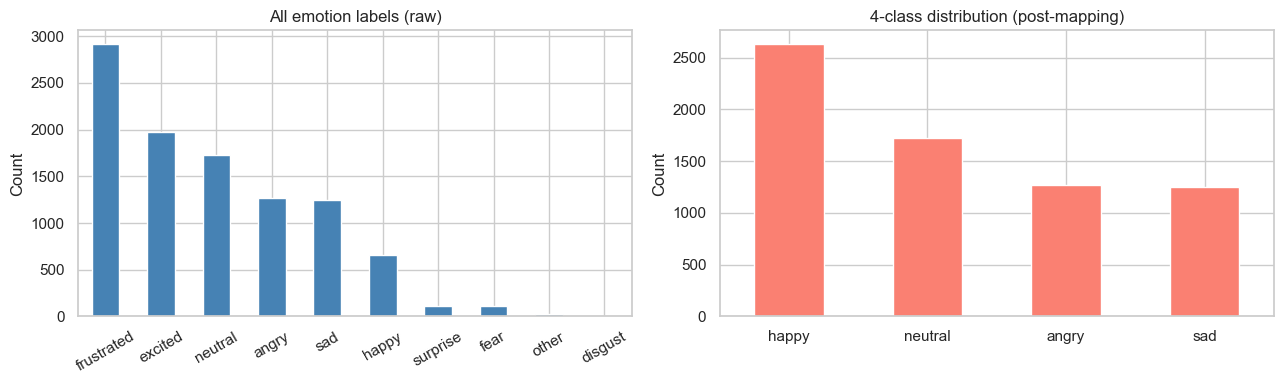

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: all raw labels — shows what was in the dataset before any filtering
df_raw['major_emotion'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('All emotion labels (raw)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Right: after applying the 4-class mapping — this is what the model will train on
df['emotion_4cls'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('4-class distribution (post-mapping)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Label Justification: Feature-Space Evidence

Two complementary views explain each decision:

**Why merge `excited → happy`**
- Their EmoAct and EmoVal distributions nearly coincide — they occupy the same region of emotion space
- Annotators who saw "excited" speech gave nearly as much probability mass to the `happy` soft label as to `excited`, and vice versa

**Why drop `frustrated`**
- In both EmoAct and EmoVal, frustrated sits between angry and neutral with heavy overlap on both sides — it has no clean home
- Annotators spread their soft-label votes across angry, neutral, sad, *and* frustrated — the class is genuinely ambiguous, not a clean variant of any single target emotion

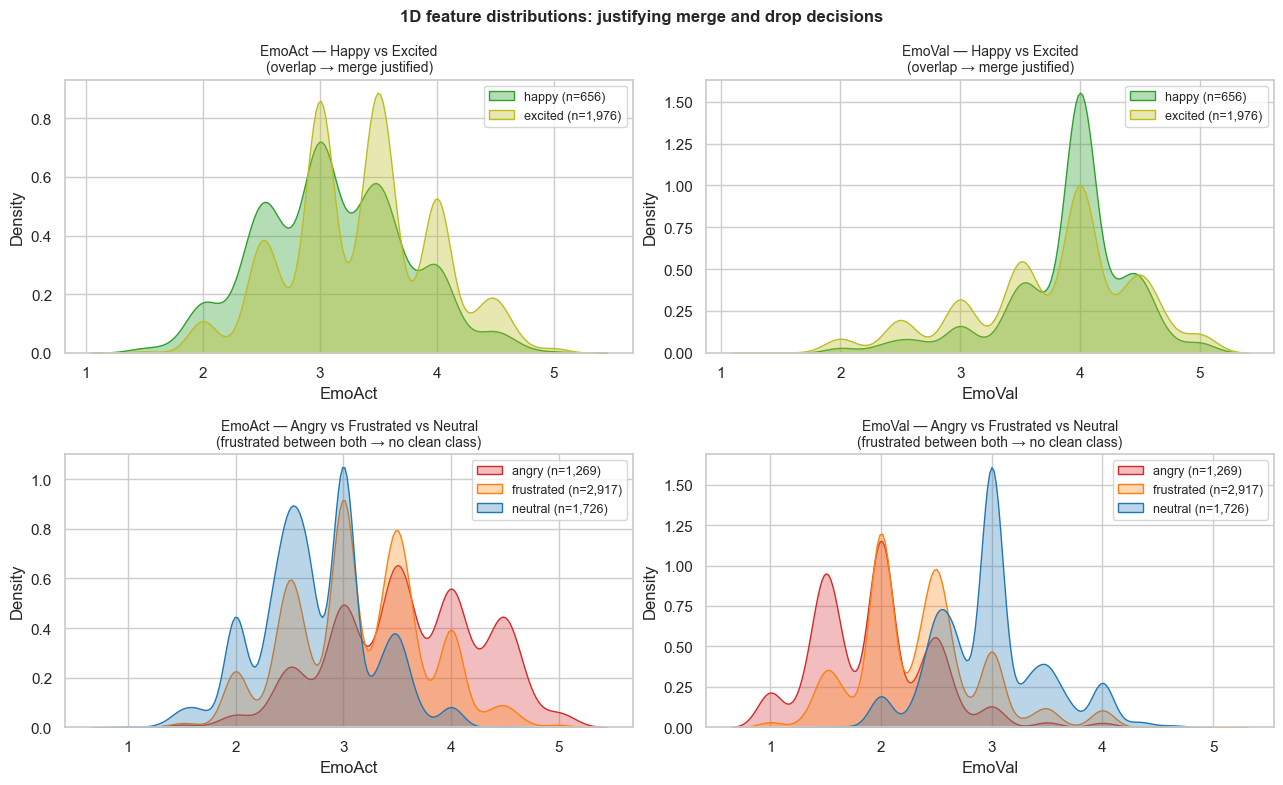

In [17]:
# ── Plot 1: 1D distribution comparison on EmoAct and EmoVal ──────────────────
# Each subplot isolates exactly one claim:
#   [top-left]  EmoAct for happy vs excited      → nearly identical → merge safe
#   [top-right] EmoVal for happy vs excited      → nearly identical → merge safe
#   [bot-left]  EmoAct for angry/frustrated/neutral → frustrated sits between them
#   [bot-right] EmoVal for angry/frustrated/neutral → same pattern on the valence axis

PALETTE = {
    'happy'     : '#2ca02c',
    'excited'   : '#bcbd22',
    'angry'     : '#d62728',
    'frustrated': '#ff7f0e',
    'neutral'   : '#1f77b4',
    'sad'       : '#9467bd',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

merge_classes = ['happy', 'excited']
drop_classes  = ['angry', 'frustrated', 'neutral']

for col_idx, vad_col in enumerate(['EmoAct', 'EmoVal']):
    # Top row: happy vs excited
    ax = axes[0][col_idx]
    for cls in merge_classes:
        subset = df_raw[df_raw['major_emotion'] == cls]
        sns.kdeplot(subset[vad_col], ax=ax, label=f'{cls} (n={len(subset):,})',
                    color=PALETTE[cls], fill=True, alpha=0.35, bw_adjust=0.9)
    ax.set_title(f'{vad_col} — Happy vs Excited\n(overlap → merge justified)', fontsize=10)
    ax.set_xlabel(vad_col); ax.legend(fontsize=9)

    # Bottom row: angry / frustrated / neutral
    ax = axes[1][col_idx]
    for cls in drop_classes:
        subset = df_raw[df_raw['major_emotion'] == cls]
        sns.kdeplot(subset[vad_col], ax=ax, label=f'{cls} (n={len(subset):,})',
                    color=PALETTE[cls], fill=True, alpha=0.30, bw_adjust=0.9)
    ax.set_title(f'{vad_col} — Angry vs Frustrated vs Neutral\n(frustrated between both → no clean class)', fontsize=10)
    ax.set_xlabel(vad_col); ax.legend(fontsize=9)

plt.suptitle('1D feature distributions: justifying merge and drop decisions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Top row:** the `happy` and `excited` curves nearly stack on both EmoAct and EmoVal — they occupy the same region of emotion space, making the merge acoustically and perceptually justified. **Bottom row:** `frustrated` has no distinct peak; its curve sits between `angry` and `neutral` on EmoAct and spans a wide range on EmoVal, confirming it has no clean home in the 4-class scheme.

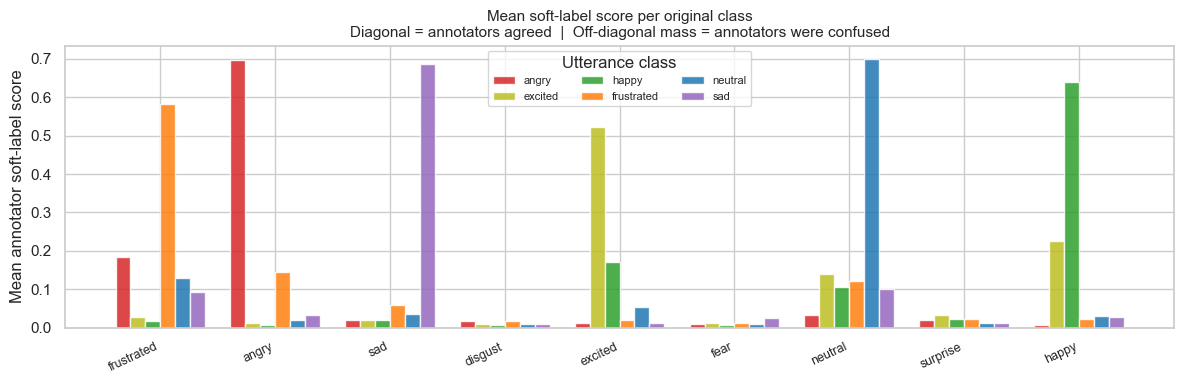

In [18]:
# ── Plot 2: Annotator soft-label "leakage" ───────────────────────────────────
# For each original emotion class, show the MEAN soft label score across all
# utterances in that class. The diagonal (class scores highest on its own column)
# means annotators agreed. Off-diagonal mass means annotators were confused.
#
# Key things to read:
#   excited row: high score on BOTH 'excited' and 'happy' columns
#                → annotators regularly confused the two → merge removes the noise
#
#   frustrated row: probability spread across 'angry', 'frustrated', 'neutral', 'sad'
#                   → no dominant neighbour → cannot cleanly merge into any one class
#                   → dropping it is safer than adding noise to another class

soft_cols   = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']
focus_cls   = ['angry', 'excited', 'happy', 'frustrated', 'neutral', 'sad']

soft_means = (
    df_raw[df_raw['major_emotion'].isin(focus_cls)]
    .groupby('major_emotion')[soft_cols]
    .mean()
    .loc[focus_cls]          # keep display order intentional
)

fig, ax = plt.subplots(figsize=(12, 4))
x      = np.arange(len(soft_cols))
width  = 0.13
colors = [PALETTE[c] for c in focus_cls]

for i, (cls, row) in enumerate(soft_means.iterrows()):
    ax.bar(x + i * width, row.values, width, label=cls, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * (len(focus_cls) - 1) / 2)
ax.set_xticklabels(soft_cols, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean annotator soft-label score')
ax.set_title(
    'Mean soft-label score per original class\n'
    'Diagonal = annotators agreed  |  Off-diagonal mass = annotators were confused',
    fontsize=11
)
ax.legend(title='Utterance class', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

`excited` shows nearly equal bars on the `excited` and `happy` columns — annotators split their votes almost evenly between the two, confirming the merge is safe. `frustrated` spreads probability across `angry`, `frustrated`, `neutral`, and `sad` with no dominant neighbour, which is why it cannot be cleanly merged into any single class and is dropped instead.

---
## Step 6 — Distribution Summary

### 6a. Pre-extracted audio features

In [19]:
# Pre-extracted acoustic features provided by the dataset:
#   speaking_rate — syllables or words per second (tempo)
#   pitch_mean    — average fundamental frequency (F0) in Hz
#   pitch_std     — variability of pitch; high std = more expressive speech
#   rms           — root mean square energy; proxy for loudness
#   relative_db   — loudness in decibels relative to a reference level
audio_features = ['speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']

# Extended describe: add skewness and kurtosis to spot heavy tails before modeling
desc = df[audio_features].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc['skew'] = df[audio_features].skew().round(3)   # |skew| > 1 → consider log transform
desc['kurt'] = df[audio_features].kurt().round(3)   # high kurtosis → heavy-tailed outliers
display(desc)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,kurt
speaking_rate,6877.0,9.182581,4.155393,0.320000,2.118000,6.240000,9.230000,12.180000,15.810000,38.709999,0.121,-0.063000
pitch_mean,6877.0,178.444489,64.993095,38.468807,94.515233,122.987328,172.022018,220.726944,292.247150,577.466858,0.766,0.689000
pitch_std,6877.0,45.228580,32.890865,0.000000,7.445225,21.946550,37.675941,60.168560,110.401285,301.505096,1.519,3.428000
rms,6877.0,0.020758,0.028912,0.000813,0.002509,0.006395,0.012490,0.023960,0.064239,0.481559,5.333,44.990002
relative_db,6877.0,-15.164677,4.189750,-34.411465,-22.364114,-17.744570,-14.967586,-12.344931,-8.604092,-2.229680,-0.381,0.509000


`rms` is heavily right-skewed (skew 5.33) and `pitch_std` is moderately skewed (1.52) — both are candidates for a log transform before modeling. `speaking_rate` is approximately normal (skew 0.12) and can be used as-is. The wide range of `pitch_mean` (38–577 Hz) reflects the mix of male and female speakers.

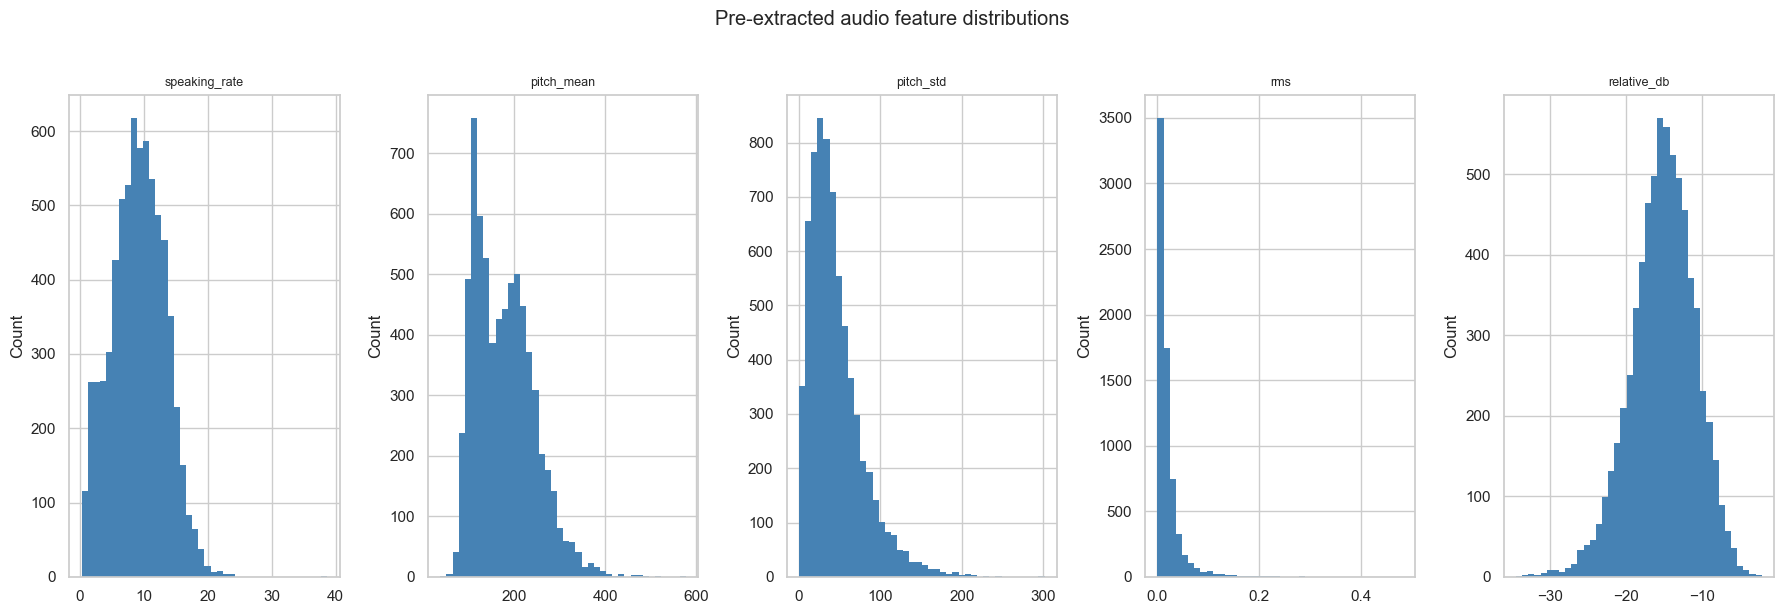

In [20]:
# Plot one histogram per audio feature to visualise the full distribution shape.
# Helps identify skew, multimodality, or unexpected gaps before running models.
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
for ax, col in zip(axes, audio_features):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count')
plt.suptitle('Pre-extracted audio feature distributions', y=1.02)
plt.tight_layout()
plt.show()

`speaking_rate` is approximately bell-shaped. `pitch_mean` is right-skewed — the long right tail reflects a subset of high-pitched female speakers. `rms` is extremely right-skewed with a sharp peak near zero and a long upper tail (confirmed by skew = 5.33). `relative_db` is roughly symmetric. `pitch_std` is moderately skewed. Log-transforming `rms` and `pitch_std` before modeling is advisable.

### 6b. Outlier detection on audio features (IQR + z-score)

In [21]:
def detect_outliers(data, cols, k=1.5, z_thresh=3.0):
    """Flag outliers in numeric columns using two complementary methods:
    - IQR: values beyond Q1 - k*IQR or Q3 + k*IQR (catches skewed distributions well)
    - Z-score: values more than z_thresh standard deviations from the mean (catches symmetric tails)
    A row is flagged if it triggers either method.
    """
    rows = []
    for col in cols:
        s = data[col].dropna()

        # IQR method
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        iqr_mask = (s < q1 - k * iqr) | (s > q3 + k * iqr)

        # Z-score method (ddof=1 for sample standard deviation)
        z_mask = ((s - s.mean()) / s.std(ddof=1)).abs() > z_thresh

        # Union: flagged by at least one method
        combined = iqr_mask | z_mask
        rows.append({
            'column': col,
            'outlier_count': int(combined.sum()),
            'outlier_pct': round(combined.mean() * 100, 2),
            'min': round(s.min(), 4), 'max': round(s.max(), 4),
            'mean': round(s.mean(), 4),
            'iqr_outliers': int(iqr_mask.sum()),
            'zscore_outliers': int(z_mask.sum()),
        })
    return pd.DataFrame(rows).sort_values('outlier_count', ascending=False)

display(detect_outliers(df, audio_features))

,column,outlier_count,outlier_pct,min,max,mean,iqr_outliers,zscore_outliers
3,rms,521,7.58,0.000800,0.481600,0.020800,521,133
2,pitch_std,269,3.91,0.000000,301.505096,45.228600,269,112
4,relative_db,92,1.34,-34.411499,-2.229700,-15.164700,92,41
1,pitch_mean,59,0.86,38.468800,577.466797,178.444504,59,49
0,speaking_rate,19,0.28,0.320000,38.709999,9.182600,19,14


`rms` has the most outliers (521, 7.6%) — consistent with its extreme right skew; a small number of very loud or near-silent utterances pull the upper tail. All flagged values appear to be genuine recordings rather than data errors, so no rows are removed. `speaking_rate` is the cleanest feature with only 19 outliers (0.3%).

In [22]:
# Adding a plot to display the outliers

### 6c. VAD scores (Valence, Activation, Dominance) by emotion class

,EmoAct,EmoVal,EmoDom
emotion_4cls,,,
angry,3.599,1.935,3.891
happy,3.285,3.805,3.202
neutral,2.729,2.984,2.854
sad,2.600,2.277,2.812


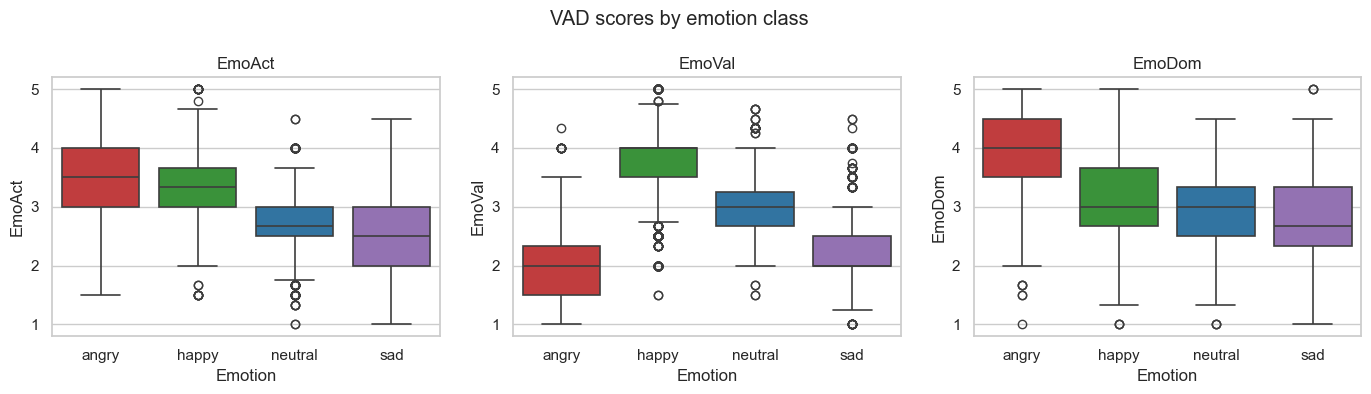

In [23]:
# VAD = Valence–Arousal–Dominance, a standard dimensional model of emotion:
#   EmoAct (Activation/Arousal) — how energetic/active the emotion is (1=calm, 5=excited)
#   EmoVal (Valence)            — how positive/negative the emotion feels (1=negative, 5=positive)
#   EmoDom (Dominance)          — how in-control/powerful the speaker feels (1=submissive, 5=dominant)
vad_cols = ['EmoAct', 'EmoVal', 'EmoDom']

# Consistent color per emotion class — used across all boxplots in the notebook
EMOTION_PALETTE = {
    'angry'  : '#d62728',
    'happy'  : '#2ca02c',
    'neutral': '#1f77b4',
    'sad'    : '#9467bd',
}

# Mean VAD scores per class reveal the emotional geometry:
# e.g. angry should be high Activation + low Valence; happy high Activation + high Valence
display(df.groupby('emotion_4cls')[vad_cols].mean().round(3))

# Boxplots show spread and overlap between classes — overlapping distributions signal harder classification
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, vad_cols):
    sns.boxplot(data=df, x='emotion_4cls', y=col, hue='emotion_4cls',
                palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
                legend=False, linewidth=1.2, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Emotion')
    ax.set_ylabel(col)
plt.suptitle('VAD scores by emotion class')
plt.tight_layout()
plt.show()

`EmoAct` cleanly separates high-arousal classes (angry, happy) from low-arousal ones (neutral, sad) — the most discriminative VAD dimension. `EmoVal` separates positive (happy) from negative (angry, sad), with neutral in the middle. `EmoDom` is weaker: angry scores highest (dominant) and sad lowest (submissive), but distributions overlap more than in the other two dimensions. All three VAD scores are useful features for the classifier.

### 6d. Soft label distributions

Each utterance has a probability score per emotion from annotators. Checking whether the `major_emotion` label aligns with the highest soft label score.

In [24]:
soft_cols = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']

# Check alignment: is major_emotion the argmax of the soft labels?
# For each utterance, find which soft label column has the highest score (the "winning" emotion).
df['soft_argmax'] = df[soft_cols].idxmax(axis=1)

# Compare the soft-label winner against the hard label — high agreement means the labels are reliable.
# Disagreement (~10%) indicates genuinely ambiguous utterances where annotators split their votes.
aligned = (df['soft_argmax'] == df['major_emotion']).mean() * 100
print(f"major_emotion == soft argmax: {aligned:.1f}% of utterances")

# Mean soft score per 4-class emotion — the diagonal should be bright (each class scores
# highest on its own soft label), with off-diagonal bleed showing natural confusability.
print("\nMean soft label score per 4-class emotion:")
display(df.groupby('emotion_4cls')[soft_cols].mean().round(3))

major_emotion == soft argmax: 90.3% of utterances

Mean soft label score per 4-class emotion:


,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy
emotion_4cls,,,,,,,,,
angry,0.184,0.697,0.021,0.018,0.012,0.008,0.034,0.019,0.007
happy,0.025,0.012,0.019,0.008,0.436,0.010,0.131,0.030,0.329
neutral,0.130,0.019,0.035,0.009,0.055,0.010,0.700,0.011,0.030
sad,0.094,0.033,0.686,0.010,0.013,0.025,0.100,0.013,0.029


-  This means in ~10% of utterances the hard label disagrees with the highest soft score, those are genuinely ambiguous utterances where the label is a judgment call, not a clear-cut case.

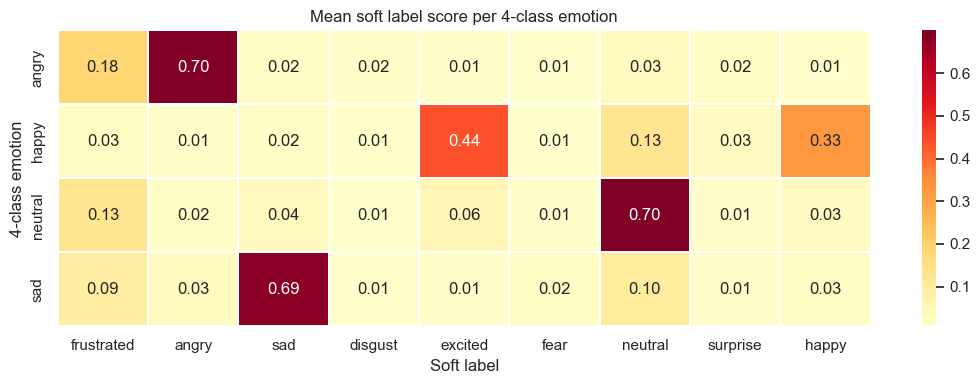

In [25]:
# Compute mean soft label score for each 4-class emotion (rows) × soft label dimension (columns)
soft_means = df.groupby('emotion_4cls')[soft_cols].mean()

# Heatmap makes the diagonal pattern easy to spot:
#   bright cell on the diagonal → that class scores high on its own soft label (clean signal)
#   bright off-diagonal cell    → two emotions are perceptually confusable (expected for angry/frustrated)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(soft_means, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Mean soft label score per 4-class emotion')
ax.set_xlabel('Soft label')
ax.set_ylabel('4-class emotion')
plt.tight_layout()
plt.show()

#### How to read this heatmap

Each **row** is one of the 4 retained emotion classes. Each **column** is one of the 9 original soft-label dimensions. The value in each cell is the mean annotator probability score for that dimension across all utterances in that row's class. A perfectly clean dataset would show a bright diagonal (every class peaks on its own column) with near-zero off-diagonal values.

---

**Row-by-row findings:**

| Class | Dominant soft label | Score | Key off-diagonal signal |
|---|---|---|---|
| **angry** | `angry` | 0.70 | `frustrated` = 0.18 — annotators regularly hedged toward frustrated when labeling angry speech |
| **happy** | `excited` | 0.44 | `happy` itself = 0.33 — the peak is *not* on the matching column; excited and happy split annotator votes almost evenly |
| **neutral** | `neutral` | 0.70 | `frustrated` = 0.13 — some neutral-sounding speech was perceived as mildly frustrated |
| **sad** | `sad` | 0.69 | `neutral` = 0.10, `frustrated` = 0.09 — sad utterances bleed into neighbouring low-arousal classes |

---

**What this confirms:**

- **Merge `excited → happy` is justified.** The `happy` row peaks on `excited` (0.44) before `happy` (0.33). Annotators assigned more probability mass to the wrong column than to the correct one — the two categories are perceptually inseparable.

- **`frustrated` is a genuine source of noise across multiple classes.** It shows up as a non-trivial off-diagonal signal in the `angry` row (0.18), the `neutral` row (0.13), and the `sad` row (0.09). It has no single natural home, which is exactly why it is dropped rather than merged.

- **`angry` and `neutral` have the cleanest boundaries** — both peak strongly at ≥ 0.70 on their own soft label, with limited confusion elsewhere.

### 6e. Transcription length distribution

count    6877.00
mean       11.31
std        10.03
min         1.00
5%          1.00
25%         4.00
50%         8.00
75%        15.00
95%        31.00
max        98.00


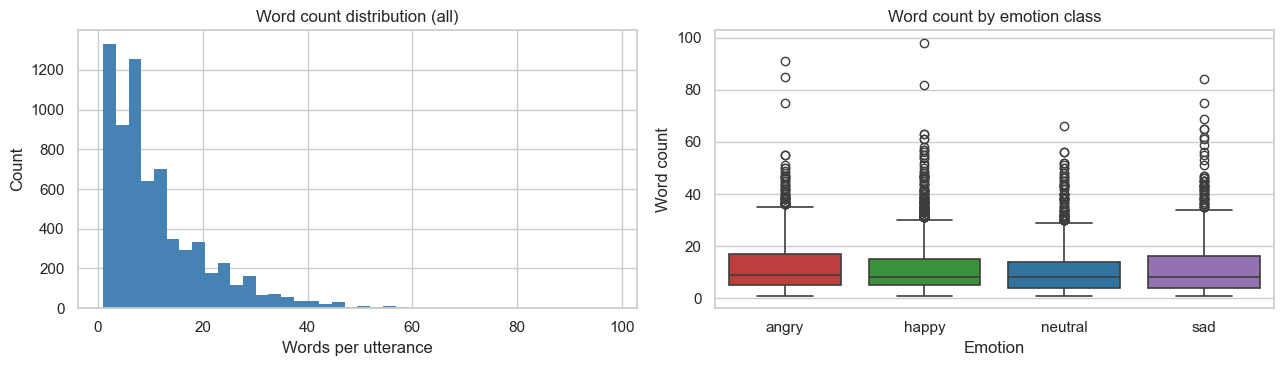

In [26]:
# Count words per utterance — a simple proxy for utterance length.
# Longer utterances may carry more textual signal for the text-based model in Sprint 2.
df['word_count'] = df['transcription'].str.split().str.len()

print(df['word_count'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overall distribution — shows if most utterances are short (typical for dyadic speech)
df['word_count'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Word count distribution (all)')
axes[0].set_xlabel('Words per utterance')
axes[0].set_ylabel('Count')

# Right: per-class breakdown — checks whether some emotions tend to be expressed in longer/shorter turns
sns.boxplot(data=df, x='emotion_4cls', y='word_count', hue='emotion_4cls',
            palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
            legend=False, linewidth=1.2, ax=axes[1])
axes[1].set_title('Word count by emotion class')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Word count')

plt.suptitle('')
plt.tight_layout()
plt.show()

Most utterances are short (median ~10 words), typical for dyadic conversational speech. Happy utterances tend to be slightly longer; angry and sad utterances tend to be shorter. The per-class differences are modest but consistent — word count is a weak signal on its own and is most useful as an auxiliary feature in a text-based model.

---
## Step 7 — Correlation Exploration

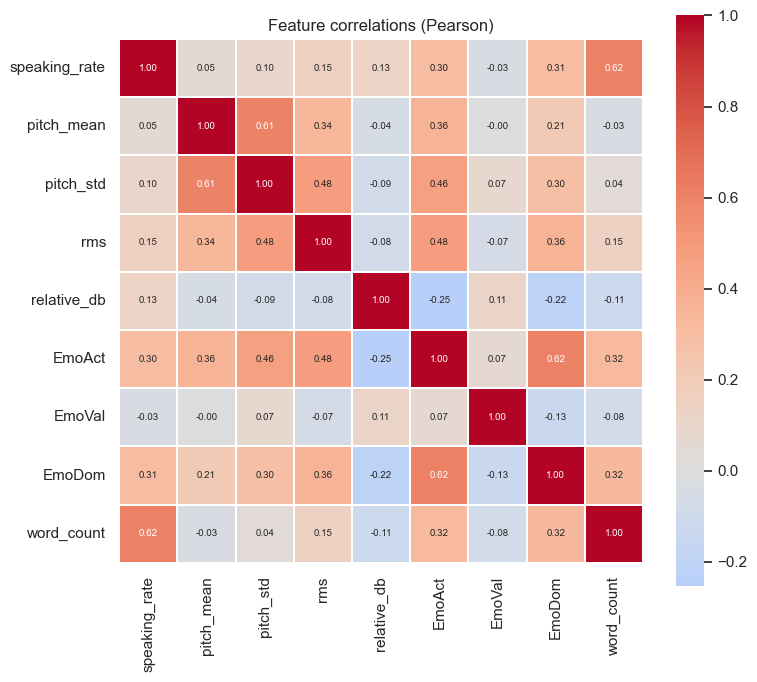

Strong pairs (|r| ≥ 0.7):
  None


In [27]:
# Combine all numeric feature groups into one list for a single correlation matrix
num_cols = audio_features + vad_cols + ['word_count']
corr = df[num_cols].corr(method='pearson')

# Flag pairs with |r| >= 0.7 as potential multicollinearity — including both in a model
# without handling this can inflate coefficients and reduce interpretability.
THRESHOLD = 0.7
pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        val = corr.iloc[i, j]
        if abs(val) >= THRESHOLD:
            pairs.append({'col_a': num_cols[i], 'col_b': num_cols[j], 'r': round(val, 4)})

# Heatmap: diverging colormap (coolwarm) centred at 0 so positive/negative correlations
# are immediately distinguishable — blue = negative, red = positive
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature correlations (Pearson)')
plt.tight_layout()
plt.show()

print(f"Strong pairs (|r| ≥ {THRESHOLD}):")
print(pd.DataFrame(pairs).to_string(index=False) if pairs else '  None')

No feature pair exceeds |r| = 0.7 — multicollinearity is not a concern and all features can be included together in a baseline model. The strongest correlations are `speaking_rate` × `word_count` (r = 0.62, both reflect utterance length) and `EmoAct` × `EmoDom` (r = 0.62, more energetic speech tends to feel more dominant). `pitch_mean` × `pitch_std` (r = 0.61) suggests that speakers with higher average pitch also vary it more.

---
## IEMOCAP-Specific Analysis

### Class balance per session (LOSO fairness check)

In [28]:
# Count utterances per (session, emotion) combination.
# fill_value=0 ensures missing combinations show up as 0 rather than being silently absent.
session_counts = df.groupby(['session', 'emotion_4cls']).size().unstack(fill_value=0)
display(session_counts)

# LOSO requires every test fold to contain all 4 classes.
# If any session is missing a class, that fold cannot produce a valid per-class recall.
missing = session_counts[session_counts == 0].stack()
if missing.empty:
    print("\nAll 4 classes present in every session — LOSO is valid.")
else:
    print(f"\nMissing class-session combinations:\n{missing}")

emotion_4cls,angry,happy,neutral,sad
session,,,,
1,270,446,392,229
2,151,518,362,212
3,286,506,327,339
4,365,549,259,159
5,197,613,386,311



All 4 classes present in every session — LOSO is valid.


All 4 classes appear in every session — LOSO is structurally valid across all 5 folds. However, within-session distributions shift considerably: session 2 has the fewest angry utterances (151) while session 4 has the most (365). This means per-fold UAR will vary and reporting mean ± std across folds is essential.

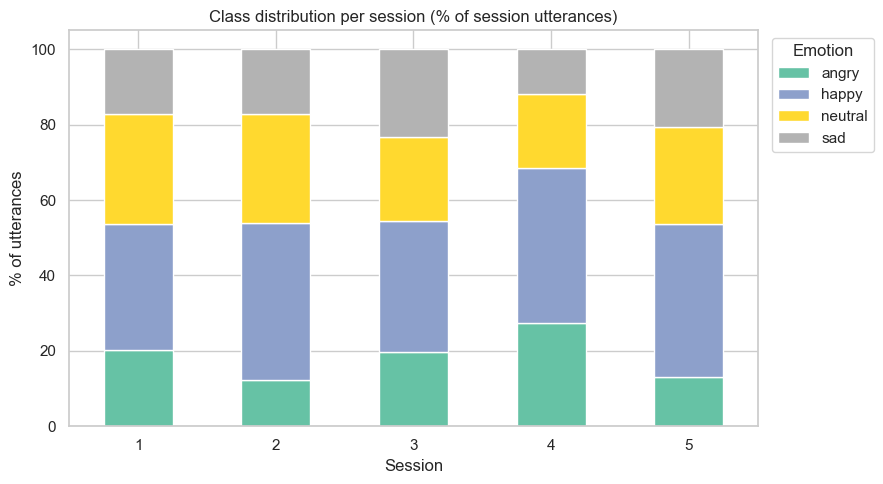

In [29]:
# Convert raw counts to percentages so sessions with different total sizes are comparable
session_pct = session_counts.div(session_counts.sum(axis=1), axis=0) * 100

# Stacked bar: each band is one emotion class; uneven band heights across sessions
# indicate that the class distribution shifts between folds — a known LOSO challenge.
ax = session_pct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')
ax.set_title('Class distribution per session (% of session utterances)')
ax.set_xlabel('Session')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The class mix shifts noticeably across sessions. Session 2 is dominated by happy utterances (~40%); session 4 has the largest angry share (~26%). This means each LOSO fold presents a slightly different class prior — a model that fits session 2's distribution well may underperform on session 4's, which is why UAR (not accuracy) must be averaged across all 5 folds.

### Gender × emotion

emotion_4cls,angry,happy,neutral,sad
gender,,,,
Female,673,1219,742,677
Male,596,1413,984,573


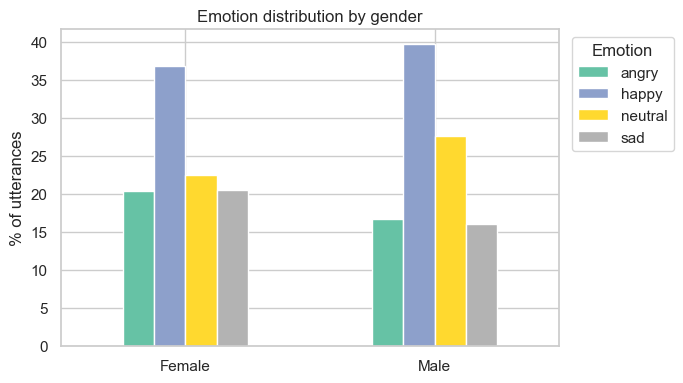

In [30]:
# Cross-tabulate utterance counts by gender and emotion class
gender_emotion = df.groupby(['gender', 'emotion_4cls']).size().unstack(fill_value=0)
display(gender_emotion)

# Normalise to percentages within each gender so the two groups are comparable
# despite having different total utterance counts (Male: 5,239 vs Female: 4,800)
gender_pct = gender_emotion.div(gender_emotion.sum(axis=1), axis=0) * 100
ax = gender_pct.plot(kind='bar', figsize=(7, 4), colormap='Set2')
ax.set_title('Emotion distribution by gender')
ax.set_xlabel('')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Female speakers produce proportionally more angry (~20% vs ~17%) and sad (~21% vs ~16%) utterances; male speakers produce more neutral (~27% vs ~22%). This means a model tested on female-only speech will face a harder angry/sad distribution than one tested on male speech, and per-gender UAR breakdowns are worth reporting to detect systematic bias.

### Method (scripted vs improvised) × emotion

emotion_4cls,angry,happy,neutral,sad
method,,,,
impro,350,1367,1108,672
script,919,1265,618,578


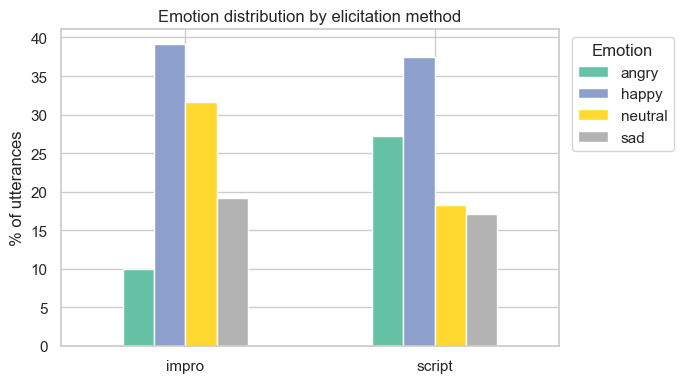

In [31]:
# Cross-tabulate utterance counts by elicitation method and emotion class.
# 'script' = actors read from a screenplay; 'impro' = unscripted emotional scenarios.
# Method affects which emotions naturally appear, so it can be a confounding variable.
method_emotion = df.groupby(['method', 'emotion_4cls']).size().unstack(fill_value=0)
display(method_emotion)

# Normalise within each method so we compare proportions, not raw counts
method_pct = method_emotion.div(method_emotion.sum(axis=1), axis=0) * 100
ax = method_pct.plot(kind='bar', figsize=(7, 4), colormap='Set2')
ax.set_title('Emotion distribution by elicitation method')
ax.set_xlabel('')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Improvised dialogue produces proportionally more angry and sad utterances; scripted reading produces more neutral and happy. A model trained on improvised data and tested on scripted (or vice versa) will encounter a shifted class prior — this is a known confounder in IEMOCAP and a direct motivation for the cross-method ablation experiment in Supporting Question 4.

### Audio features by emotion class

,speaking_rate,pitch_mean,pitch_std,rms,relative_db
emotion_4cls,,,,,
angry,10.231,207.613998,61.173000,0.042,-17.061001
happy,9.384,184.231995,51.999001,0.022,-15.115000
neutral,9.296,159.156998,35.462002,0.013,-14.228000
sad,7.536,163.278000,28.271000,0.007,-14.636000


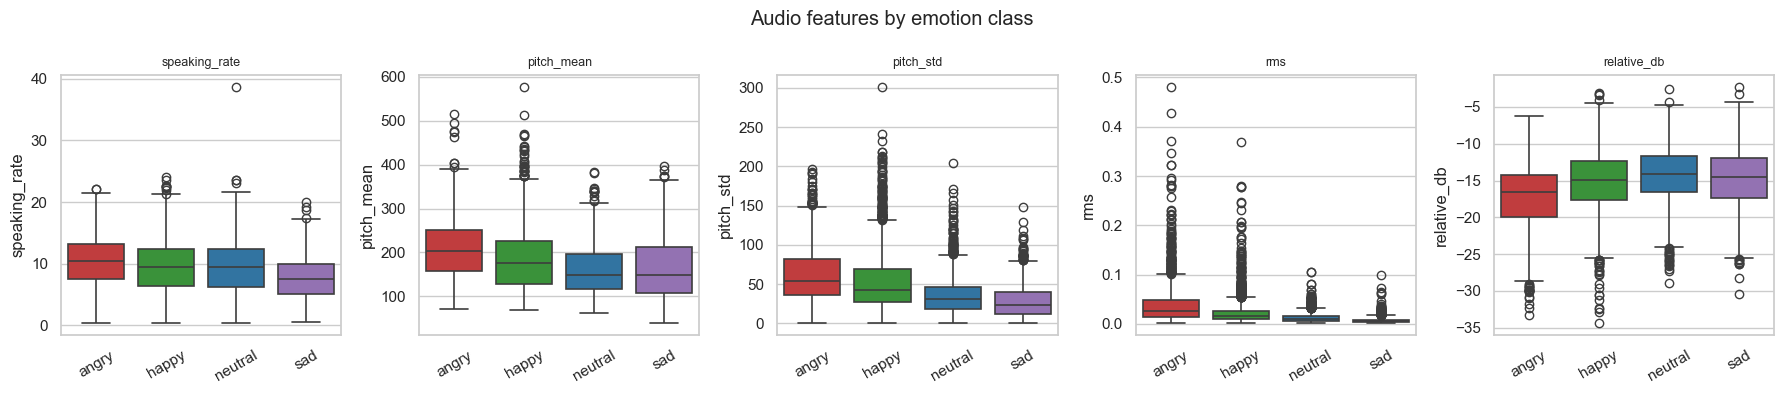

In [32]:
# Mean audio feature value per emotion class — a quick check for emotion-discriminative signal.
# Large differences between classes → the feature will be useful for the classifier.
display(df.groupby('emotion_4cls')[audio_features].mean().round(3))

# Boxplots reveal the full distribution and spread, not just the mean.
# Overlapping boxes between classes indicate lower discriminability for that feature.
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, audio_features):
    sns.boxplot(data=df, x='emotion_4cls', y=col, hue='emotion_4cls',
                palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
                legend=False, linewidth=1.2, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Audio features by emotion class')
plt.tight_layout()
plt.show()

**Key observations:**

- **`speaking_rate`** — angry utterances are slightly faster than sad; the difference is modest and distributions overlap heavily across all four classes.
- **`pitch_mean`** — angry and happy sit higher (median ~200 Hz) than neutral and sad (~150–170 Hz). The large spread and many high outliers reflect the mix of male (lower pitch) and female (higher pitch) speakers within each class.
- **`pitch_std`** — angry and happy show greater pitch variability (more expressive intonation); sad has the lowest variability, consistent with flat, monotone delivery.
- **`rms` / `relative_db`** — angry is the loudest class; sad is the quietest. Both features show the same pattern, confirming they measure the same underlying signal (energy).

Overall: `pitch_mean`, `rms`, and `relative_db` are the most emotion-discriminative features — they cleanly separate **high-arousal** (angry, happy) from **low-arousal** (neutral, sad) classes and are strong candidates for the Sprint 2 feature set.

### Class imbalance ratio (UAR context)

In [33]:
# Count utterances per class to quantify how imbalanced the dataset is
class_counts = df['emotion_4cls'].value_counts()

# Imbalance ratio = largest class / smallest class.
# A ratio of 1.0 means perfect balance; higher values mean the model can gain accuracy
# by simply predicting the majority class — which is why UAR (not accuracy) is used.
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class counts:")
for cls, cnt in class_counts.items():
    bar = '█' * int(cnt / 50)   # one block per 50 utterances — visual bar chart in text
    print(f"  {cls:<10} {cnt:>5}  {bar}")

print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")
print("UAR (macro recall) is the right primary metric — weights all classes equally.")

Class counts:
  happy       2632  ████████████████████████████████████████████████████
  neutral     1726  ██████████████████████████████████
  angry       1269  █████████████████████████
  sad         1250  █████████████████████████

Imbalance ratio (max/min): 2.11x
UAR (macro recall) is the right primary metric — weights all classes equally.


---
## Findings Summary

1. **No missing values** — all 22 columns are complete across 10,039 utterances.

2. **Label drop rate** — after applying the 4-class mapping, `frustrated` (~18%) and other minority emotions are dropped. See Step 5 for exact counts.

3. **Class imbalance is moderate** — UAR (macro recall) is the correct primary metric as it weights all 4 classes equally regardless of count.

4. **LOSO is valid** — all 4 emotion classes appear in every session. All 5 LOSO folds are structurally usable.

5. **Pre-extracted audio features show emotion signal** — `pitch_mean`, `rms`, and `speaking_rate` visibly differ across emotion classes (see boxplots). These are viable Sprint 2 features.

6. **VAD scores are discriminative** — `EmoAct` (activation) separates angry/excited from sad/neutral; `EmoVal` (valence) separates happy from angry/sad. Useful as auxiliary features.

7. **Scripted vs improvised imbalance** — `impro` produces more utterances and has a different emotion distribution. Consider including `method` as a covariate.

**Next step:** Sprint 2 — Feature engineering: TF-IDF on `transcription` + MFCC/eGeMAPS on raw audio + early fusion baseline with LOSO cross-validation.